# 🔧 SentinelIQ — Notebook 02: Feature Engineering

This notebook walks through the complete feature engineering pipeline implemented in `src/features.py`, visualising each transformation step with before/after comparisons.

---

## Pipeline Steps

```
Raw DataFrame
     │
     ▼  Step 1: compute_rul()        — RUL = max_cycle − cycle
     ▼  Step 2: cap_rul()            — Piece-wise linear cap at 125
     ▼  Step 3: _cluster_op_cond()   — K-Means on op_settings (FD002/004)
     ▼  Step 4: remove_constants()   — Drop near-zero-variance sensors
     ▼  Step 5: normalize()          — StandardScaler z-score
     │
     ▼
Processed DataFrame + feature_cols list
```

In [1]:
# ── Environment setup ──────────────────────────────────────────────────────────
import sys
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd()).parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from src.config import config
from src.data_loader import CMAPSSLoader
from src.features import FeatureEngineer

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
COLORS = sns.color_palette('husl', 8)
print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# ── Load data (real or synthetic) ─────────────────────────────────────────────
DATA_DIR = REPO_ROOT / 'data' / 'raw'
loader = CMAPSSLoader(data_dir=DATA_DIR)

try:
    train_raw, test_raw, rul_df = loader.load_single_dataset('FD001')
    print(f"✅ Real FD001 data loaded: train={train_raw.shape}, test={test_raw.shape}")
except FileNotFoundError:
    print("⚠️  Real data not found. Generating synthetic dataset...")
    np.random.seed(42)
    cols = ['unit_id','cycle','op_setting_1','op_setting_2','op_setting_3'] + \
           [f'sensor_{i}' for i in range(1, 22)]
    rows = []
    for uid in range(1, 101):
        life = np.random.randint(100, 250)
        for c in range(1, life + 1):
            # Simulate degradation: sensor values drift as cycle increases
            degradation = c / life
            sensors = np.random.randn(21) + degradation * np.random.choice([-1, 1], 21)
            # Make some sensors constant (like real FD001)
            for const_idx in [0, 4, 9, 15, 17, 18]:  # sensor_1,5,10,16,18,19
                sensors[const_idx] = 0.0
            row = [uid, c, 0.0, 0.0002, 100.0] + sensors.tolist()
            rows.append(row)
    train_raw = pd.DataFrame(rows, columns=cols).astype({'unit_id': 'int32', 'cycle': 'int32'})
    test_rows = []
    for uid in range(1, 101):
        life = np.random.randint(50, 150)
        for c in range(1, life + 1):
            sensors = np.random.randn(21)
            for const_idx in [0, 4, 9, 15, 17, 18]:
                sensors[const_idx] = 0.0
            row = [uid, c, 0.0, 0.0002, 100.0] + sensors.tolist()
            test_rows.append(row)
    test_raw = pd.DataFrame(test_rows, columns=cols).astype({'unit_id': 'int32', 'cycle': 'int32'})
    rul_df = pd.DataFrame({'RUL': np.random.randint(0, 80, size=100)})
    print(f"📊 Synthetic: train={train_raw.shape}, test={test_raw.shape}")

✅ Real FD001 data loaded: train=(20631, 26), test=(13096, 26)


## Step 1 — Compute RUL

In [3]:
# ── Step 1: Compute RUL ────────────────────────────────────────────────────────
fe = FeatureEngineer(
    rul_cap=config.rul_cap,
    variance_threshold=config.variance_threshold,
    n_operating_clusters=config.n_operating_clusters,
    random_seed=config.random_seed,
)

train_step1 = fe.compute_rul(train_raw)

print("RUL added to training set:")
print(f"  Min RUL : {train_step1['RUL'].min()}")
print(f"  Max RUL : {train_step1['RUL'].max()}")
print(f"  Mean RUL: {train_step1['RUL'].mean():.1f}")
print()
print("Example — Unit 1 (first 5 and last 5 cycles):")
unit1 = train_step1[train_step1['unit_id'] == 1][['cycle', 'RUL']]
print(pd.concat([unit1.head(), unit1.tail()]))

RUL added to training set:
  Min RUL : 0
  Max RUL : 361
  Mean RUL: 107.8

Example — Unit 1 (first 5 and last 5 cycles):
     cycle  RUL
0        1  191
1        2  190
2        3  189
3        4  188
4        5  187
187    188    4
188    189    3
189    190    2
190    191    1
191    192    0


## Step 2 — Piece-Wise Linear RUL Capping

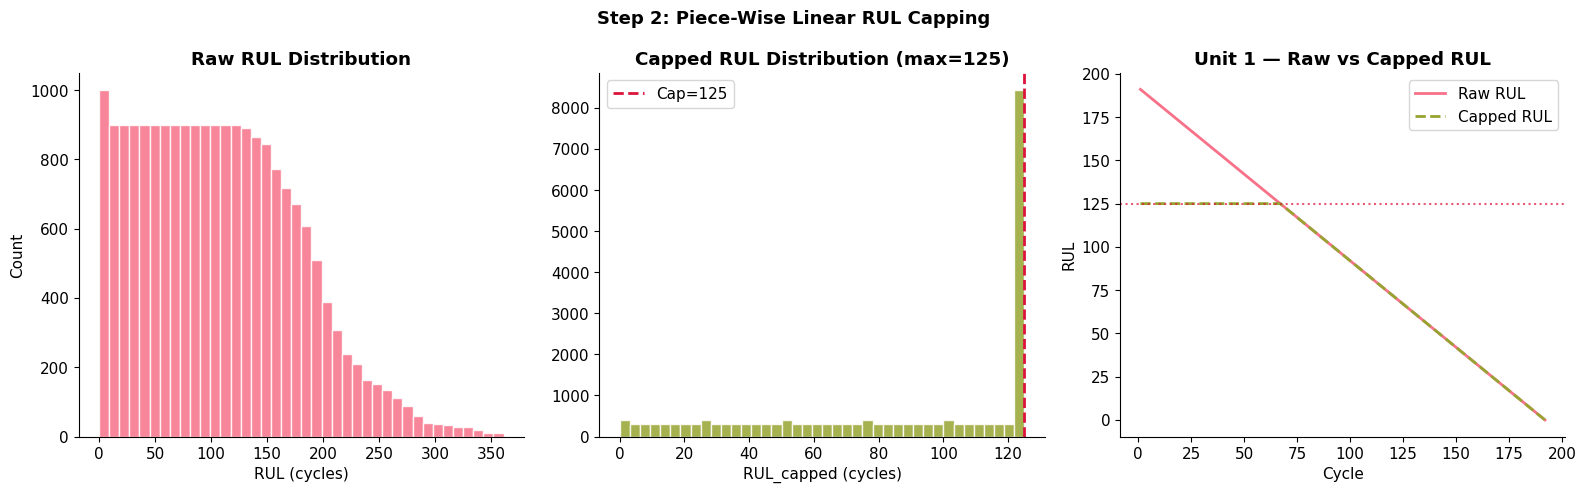

  Rows affected by capping: 8,031 (38.9%)
  Rationale: RUL=300 and RUL=200 are both 'healthy' — no need to distinguish them.


In [4]:
# ── Step 2: RUL capping visualisation ─────────────────────────────────────────
train_step2 = fe.cap_rul(train_step1)
RUL_CAP = config.rul_cap

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: raw RUL distribution
axes[0].hist(train_step2['RUL'], bins=40, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Raw RUL Distribution', fontweight='bold')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')

# Middle: capped RUL distribution
axes[1].hist(train_step2['RUL_capped'], bins=40, color=COLORS[2], edgecolor='white', alpha=0.85)
axes[1].axvline(RUL_CAP, color='crimson', lw=2, linestyle='--', label=f'Cap={RUL_CAP}')
axes[1].set_title(f'Capped RUL Distribution (max={RUL_CAP})', fontweight='bold')
axes[1].set_xlabel('RUL_capped (cycles)')
axes[1].legend()

# Right: before vs after for a single unit
unit1_data = train_step2[train_step2['unit_id'] == 1].sort_values('cycle')
axes[2].plot(unit1_data['cycle'], unit1_data['RUL'], label='Raw RUL', color=COLORS[0], lw=2)
axes[2].plot(unit1_data['cycle'], unit1_data['RUL_capped'], label='Capped RUL',
             color=COLORS[2], lw=2, linestyle='--')
axes[2].axhline(RUL_CAP, color='crimson', lw=1.5, linestyle=':', alpha=0.7)
axes[2].set_title('Unit 1 — Raw vs Capped RUL', fontweight='bold')
axes[2].set_xlabel('Cycle')
axes[2].set_ylabel('RUL')
axes[2].legend()

plt.suptitle('Step 2: Piece-Wise Linear RUL Capping', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'fe_rul_capping.png', dpi=150, bbox_inches='tight')
plt.show()

n_affected = (train_step2['RUL'] != train_step2['RUL_capped']).sum()
print(f"  Rows affected by capping: {n_affected:,} ({100*n_affected/len(train_step2):.1f}%)")
print("  Rationale: RUL=300 and RUL=200 are both 'healthy' — no need to distinguish them.")

## Step 3 — Operating Condition Clustering

For FD001/FD003 (single regime): op_settings have near-zero variance → clustering skipped, all units assigned cluster 0.

For FD002/FD004 (6 regimes): K-Means clusters the (op_setting_1, op_setting_2, op_setting_3) space.

Operating condition std dev (FD001):
  op_setting_1: 0.002187  ✅ Single regime (std near 0)
  op_setting_2: 0.000293  ✅ Single regime (std near 0)
  op_setting_3: 0.000000  ✅ Single regime (std near 0)

For FD002/FD004, K-Means would cluster 6 distinct operating points.
Demonstrating K-Means elbow curve on synthetic multi-regime data...


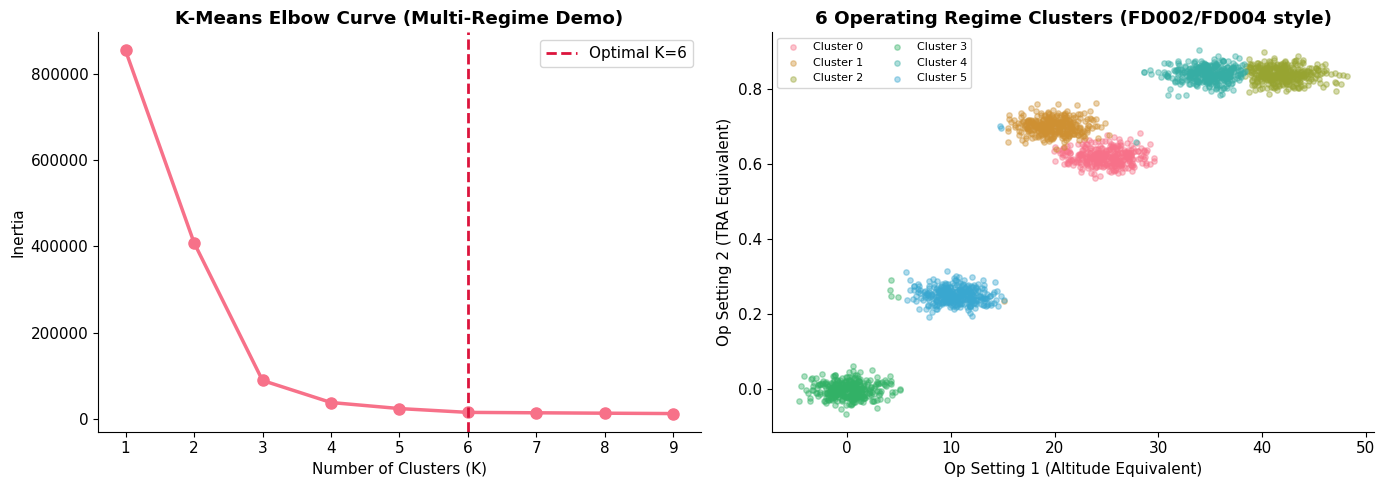

In [5]:
# ── Step 3: Operating condition clustering ─────────────────────────────────────
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
op_variance = train_step2[op_cols].std()
print("Operating condition std dev (FD001):")
for col, std in op_variance.items():
    single = '✅ Single regime (std near 0)' if std < 0.01 else '⚙️  Multi-regime'
    print(f"  {col}: {std:.6f}  {single}")

print()
print("For FD002/FD004, K-Means would cluster 6 distinct operating points.")
print("Demonstrating K-Means elbow curve on synthetic multi-regime data...")

# Simulate multi-regime data for demonstration
np.random.seed(42)
n_points = 2000
# 6 clusters representing altitude/throttle combinations
centers = np.array([[0, 0.0002, 100], [10, 0.25, 100], [20, 0.7, 100],
                    [25, 0.62, 60],   [35, 0.84, 100], [42, 0.84, 100]])
demo_data = np.vstack([c + np.random.randn(n_points // 6, 3) * [2, 0.02, 2] for c in centers])

# Elbow curve
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(demo_data)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'o-', color=COLORS[0], lw=2.5, markersize=8)
axes[0].axvline(6, color='crimson', linestyle='--', lw=2, label='Optimal K=6')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Curve (Multi-Regime Demo)', fontweight='bold')
axes[0].legend()

# Cluster scatter
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = km_final.fit_predict(demo_data)
for cluster_id in range(6):
    mask = labels == cluster_id
    axes[1].scatter(demo_data[mask, 0], demo_data[mask, 1],
                    alpha=0.4, s=15, label=f'Cluster {cluster_id}', color=COLORS[cluster_id])
axes[1].set_xlabel('Op Setting 1 (Altitude Equivalent)')
axes[1].set_ylabel('Op Setting 2 (TRA Equivalent)')
axes[1].set_title('6 Operating Regime Clusters (FD002/FD004 style)', fontweight='bold')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'fe_op_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Remove Constant Sensors

In [6]:
# ── Step 4: Constant sensor removal ───────────────────────────────────────────
# Run full process to get the results
fe2 = FeatureEngineer(
    rul_cap=config.rul_cap,
    variance_threshold=config.variance_threshold,
    n_operating_clusters=config.n_operating_clusters,
    random_seed=config.random_seed,
)

train_proc, test_proc, feature_cols = fe2.process(train_raw.copy(), test_raw.copy())

print(f"Constant sensors removed  : {fe2._constant_sensors}")
print(f"Informative sensors kept  : {len(feature_cols)}")
print(f"Final feature columns     : {feature_cols}")

# Before/after column counts
sensor_cols_before = [c for c in train_raw.columns if c.startswith('sensor_')]
print(f"\nSensors before: {len(sensor_cols_before)}")
print(f"Sensors after : {len([c for c in feature_cols if c.startswith('sensor_')])}")

Constant sensors removed  : ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Informative sensors kept  : 15
Final feature columns     : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Sensors before: 21
Sensors after : 15


## Step 5 — StandardScaler Normalisation

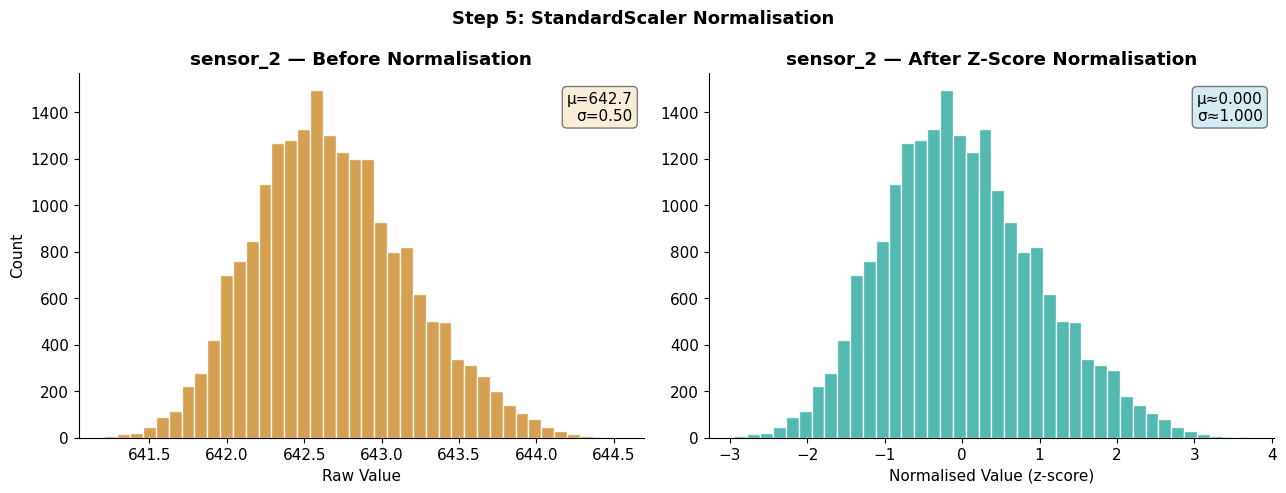

✅ Scaler fitted on TRAIN only — applied to test with same parameters (no leakage)


In [7]:
# ── Step 5: Normalisation before/after ────────────────────────────────────────
# Compare distribution of a key sensor before and after normalisation
DEMO_SENSOR = feature_cols[0] if feature_cols else 'sensor_2'

# Raw sensor values (before engineering)
raw_values = train_raw[DEMO_SENSOR].values if DEMO_SENSOR in train_raw.columns else np.random.randn(1000) * 3 + 550
# Normalised values (from processed df)
norm_values = train_proc[DEMO_SENSOR].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(raw_values, bins=40, color=COLORS[1], edgecolor='white', alpha=0.85)
axes[0].set_title(f'{DEMO_SENSOR} — Before Normalisation', fontweight='bold')
axes[0].set_xlabel('Raw Value')
axes[0].set_ylabel('Count')
axes[0].text(0.98, 0.95, f'μ={np.mean(raw_values):.1f}\nσ={np.std(raw_values):.2f}',
             ha='right', va='top', transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].hist(norm_values, bins=40, color=COLORS[4], edgecolor='white', alpha=0.85)
axes[1].set_title(f'{DEMO_SENSOR} — After Z-Score Normalisation', fontweight='bold')
axes[1].set_xlabel('Normalised Value (z-score)')
axes[1].text(0.98, 0.95, f'μ≈{np.mean(norm_values):.3f}\nσ≈{np.std(norm_values):.3f}',
             ha='right', va='top', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.suptitle('Step 5: StandardScaler Normalisation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'fe_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scaler fitted on TRAIN only — applied to test with same parameters (no leakage)")

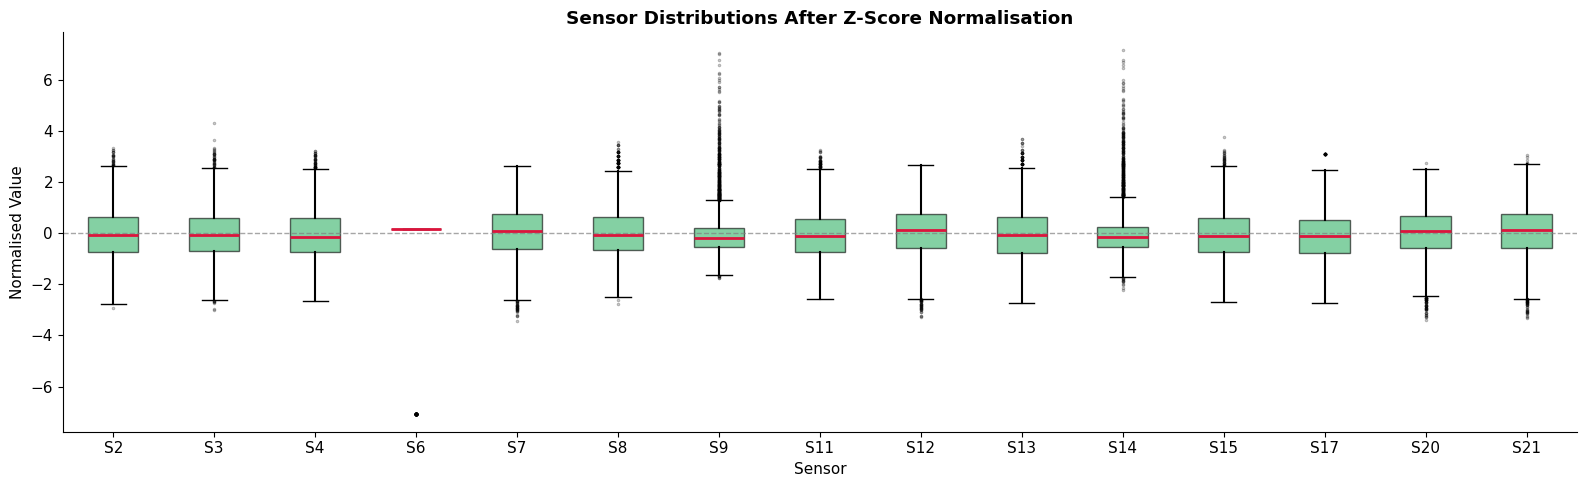

In [8]:
# ── All features boxplot after normalisation ──────────────────────────────────
sensor_feature_cols = [c for c in feature_cols if c.startswith('sensor_')]
fig, ax = plt.subplots(figsize=(16, 5))

sample_data = train_proc[sensor_feature_cols].sample(min(5000, len(train_proc)), random_state=42)
ax.boxplot(
    [sample_data[col].dropna().values for col in sensor_feature_cols],
    labels=[col.replace('sensor_', 'S') for col in sensor_feature_cols],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS[3], alpha=0.6),
    medianprops=dict(color='crimson', lw=2),
    whiskerprops=dict(lw=1.5),
    flierprops=dict(marker='.', markersize=3, alpha=0.3)
)
ax.axhline(0, color='gray', linestyle='--', lw=1, alpha=0.7)
ax.set_title('Sensor Distributions After Z-Score Normalisation', fontweight='bold')
ax.set_xlabel('Sensor')
ax.set_ylabel('Normalised Value')

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'fe_normalised_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering Summary

| Step | Operation | Input | Output | Impact |
|------|-----------|-------|--------|--------|
| 1 | `compute_rul()` | Raw cycles | + RUL column | Enables supervised learning |
| 2 | `cap_rul()` | RUL | + RUL_capped | Removes early-lifecycle noise |
| 3 | `_cluster_op_cond()` | op_settings | + op_cluster | Multi-regime conditioning |
| 4 | `remove_constant_sensors()` | 21 sensors | Drop 6 constants | Removes zero-info features |
| 5 | `normalize()` | Raw sensor values | Z-score (μ=0, σ=1) | Stable gradient training |

---

**Next:** `03_model_evaluation.ipynb` — Training LSTM/TCN models and comparing their performance.